# Q9.
```{admonition}
:class: note
This question uses the variables `dis` (the weighted mean of distances to five Boston employment centers) and `nox` (nitrogen oxides concentration in parts per 10 million) from the `Boston` data. We will treat `dis` as the predictor and `nox` as the response.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, train_test_split

In [3]:
import seaborn as sns

In [39]:
rng = np.random.default_rng(1728)

In [4]:
boston = pd.read_csv('../../ALL CSV FILES - 2nd Edition/Boston.csv',index_col=0)

In [6]:
boston.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
129,0.32543,0.0,21.89,0,0.624,6.431,98.8,1.8125,4,437,21.2,15.39,18.0
352,0.07950,60.0,1.69,0,0.411,6.579,35.9,10.7103,4,411,18.3,5.49,24.1
196,0.01381,80.0,0.46,0,0.422,7.875,32.0,5.6484,4,255,14.4,2.97,50.0


In [36]:
X = boston[['dis']]
y = boston['nox']

## (a)
```{admonition}
:class: note
Fit a cubic polynomial regression to predict `nox` using `dis`. Report the regression output, and plot the resulting data and polynomial fits.

In [38]:
pipe = Pipeline(
    [
        ('poly',PolynomialFeatures(include_bias=True, degree=3)),('lr',LinearRegression(fit_intercept=False))
    ]

)

pipe.fit(X,y)
print('Regression fit is:',str(round(pipe.named_steps['lr'].coef_[0],4))+''.join([f'+{b:.4f}x^{i+1}' if b>0 else f'{b:.4f}x^{i+1}' for i,b in enumerate(pipe.named_steps['lr'].coef_[1:])]))

Regression fit is: 0.9341-0.1821x^1+0.0219x^2-0.0009x^3


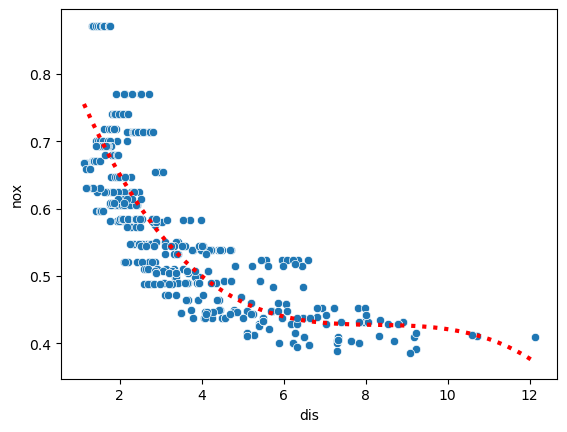

In [47]:
xs = pd.DataFrame({'dis':np.linspace(X.min().values[0],X.max().values[0])})
ys = pipe.predict(xs)
plt.plot(xs,ys,'r:',linewidth=3)

sns.scatterplot(data=boston,x='dis',y='nox')
plt.show()

## (b)
```{admonition}
:class: note
Plot the polynomial fits for a range of different polynomial degrees (say, from 1 to 10), and report the associated residual sum of squares.

Degree 1 model RSS: 0.2736
Degree 2 model RSS: 0.2011
Degree 3 model RSS: 0.1911
Degree 4 model RSS: 0.1910
Degree 5 model RSS: 0.1893
Degree 6 model RSS: 0.1856
Degree 7 model RSS: 0.1828
Degree 8 model RSS: 0.1814
Degree 9 model RSS: 0.1812
Degree 10 model RSS: 0.1817


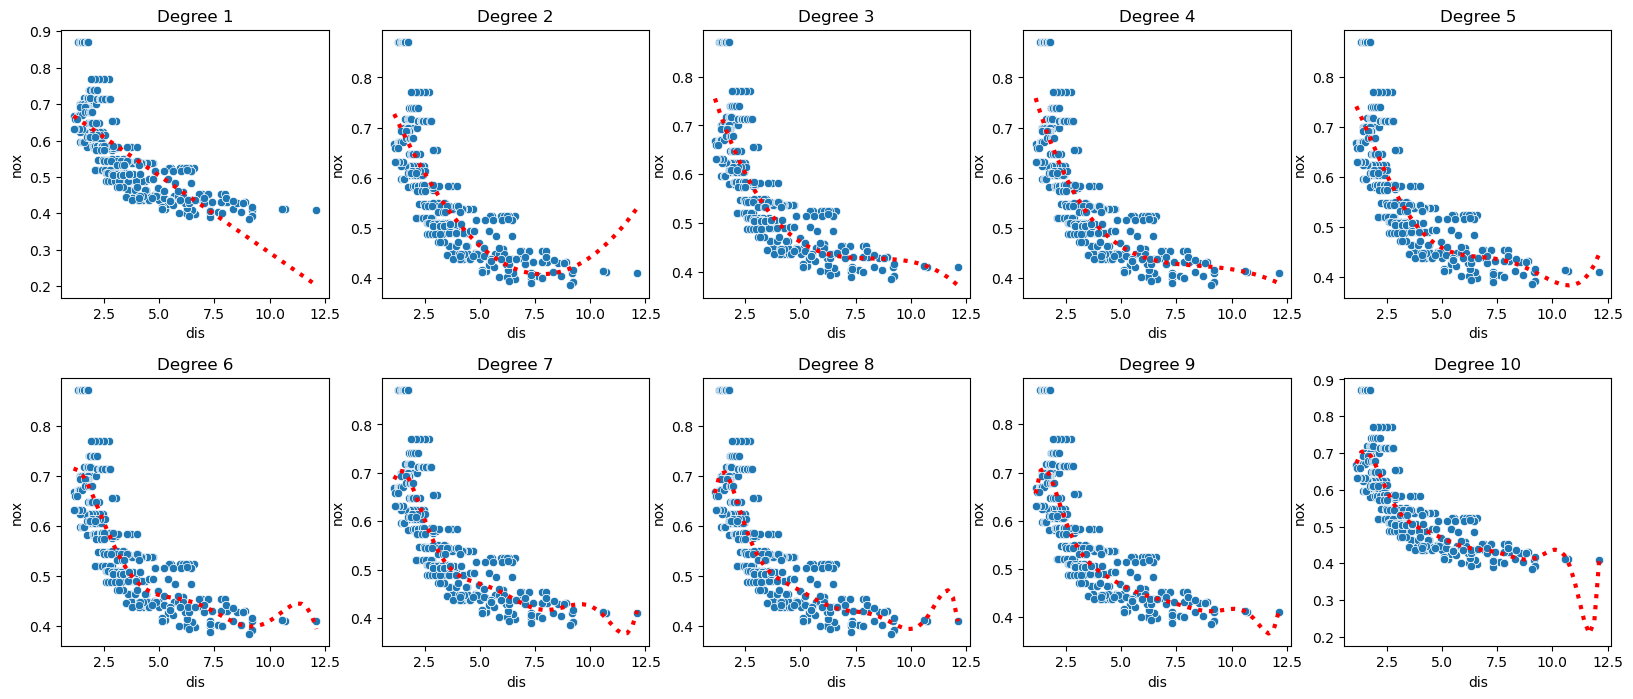

In [101]:
fig,ax = plt.subplots(2,5,figsize=(20,8))
fig.subplots_adjust(hspace=0.3)
ax = ax.flatten()
xs = pd.DataFrame({'dis':np.linspace(X.min().values[0],X.max().values[0])})
rss = np.zeros(10)
for d,axis in enumerate(ax):
    pipe = Pipeline(
        [
            ('poly',PolynomialFeatures(include_bias=False, degree=d+1)),('lr',LinearRegression())
        ]
    )
    pipe.fit(X,y) 
    ys = pipe.predict(xs)
    y_pred = pipe.predict(X)
    rss[d] = len(ys)*mean_squared_error(y_pred,y)
    axis.plot(xs,ys,'r:',linewidth=3)
    sns.scatterplot(data=boston,x='dis',y='nox',ax=axis)
    axis.set_title(f'Degree {d+1}')
for d,model_rss in enumerate(rss):
    print(f'Degree {d+1} model RSS: {model_rss:.4f}')
plt.show()

Degree 1 model RSS: 0.2736
Degree 2 model RSS: 0.2011
Degree 3 model RSS: 0.1911
Degree 4 model RSS: 0.1910
Degree 5 model RSS: 0.1893
Degree 6 model RSS: 0.1856
Degree 7 model RSS: 0.1828
Degree 8 model RSS: 0.1814
Degree 9 model RSS: 0.1812
Degree 10 model RSS: 0.1810


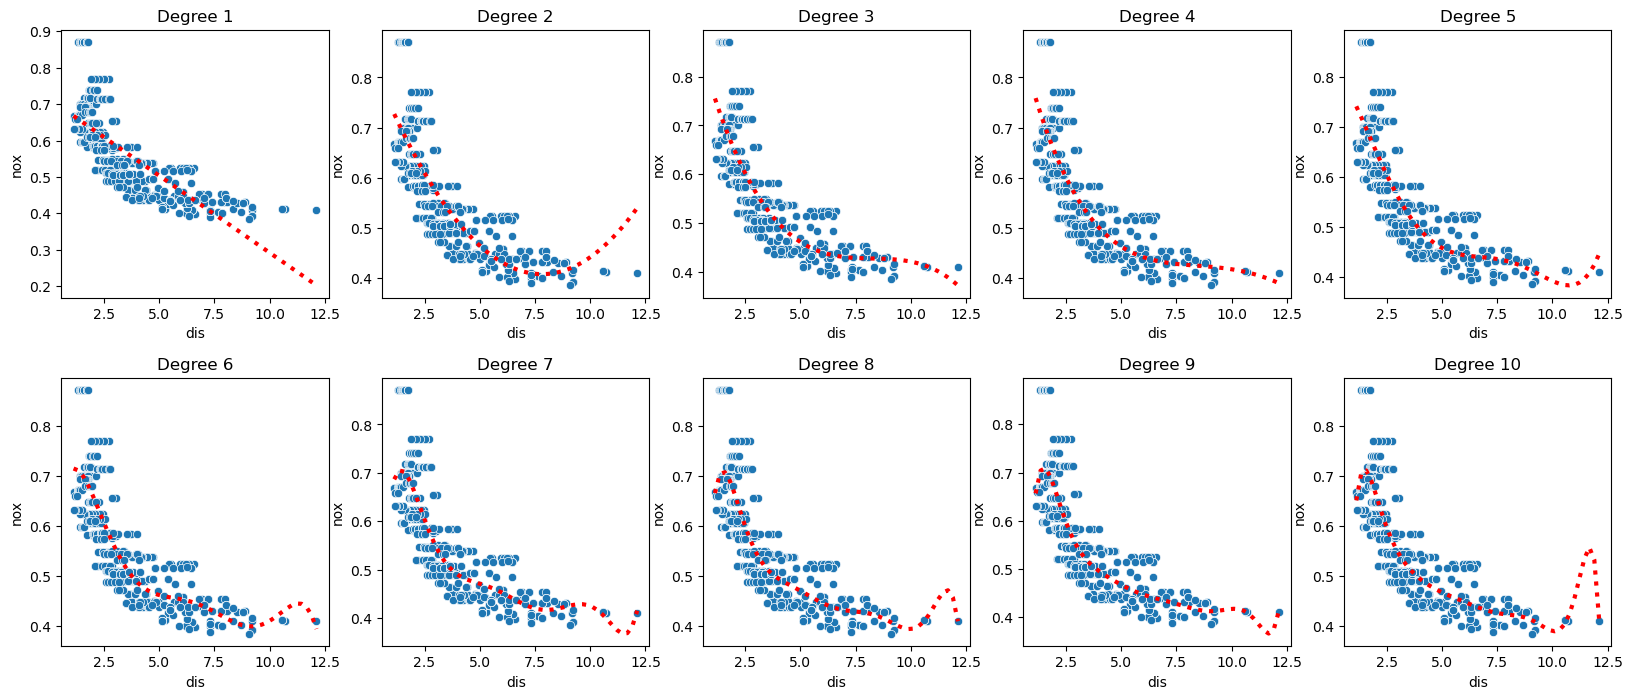

In [102]:
fig,ax = plt.subplots(2,5,figsize=(20,8))
fig.subplots_adjust(hspace=0.3)
ax = ax.flatten()
xs = pd.DataFrame({'dis':np.linspace(X.min().values[0],X.max().values[0])})
rss = np.zeros(10)
for d,axis in enumerate(ax):
    model = np.polynomial.Legendre.fit(X.values[:,0],y,deg=d+1) 
    ys = model(xs)
    y_pred = model(X.values[:,0])
    rss[d] = len(ys)*mean_squared_error(y_pred,y)
    axis.plot(xs,ys,'r:',linewidth=3)
    sns.scatterplot(data=boston,x='dis',y='nox',ax=axis)
    axis.set_title(f'Degree {d+1}')
for d,model_rss in enumerate(rss):
    print(f'Degree {d+1} model RSS: {model_rss:.4f}')
plt.show()

## (c)
```{admonition}
:class: note
Perform cross-validation or another approach to select the optimal degree for the polynomial.

In [80]:
pipe = Pipeline(
    [
        ('poly',PolynomialFeatures(include_bias=False)),('lr',LinearRegression())
    ]

)
inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
degrees = np.arange(1,11)

gridsearch = GridSearchCV(pipe,{'poly__degree':degrees},scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_mse = -cross_val_score(gridsearch,X,y,cv=outer_cv).mean()

gridsearch.fit(X,y)
best_degree = gridsearch.best_params_['poly__degree']

print(f'CV average MSE: {cv_mse:.4f}')
print(f'Degree used: {best_degree}')

CV average MSE: 0.0088
Degree used: 3


## (d)
```{admonition}
:class: note
Fit a cubic regression spline to predict `nox` using `dis`. Report the output for the fit using four degrees of freedom. Plot the resulting fit.

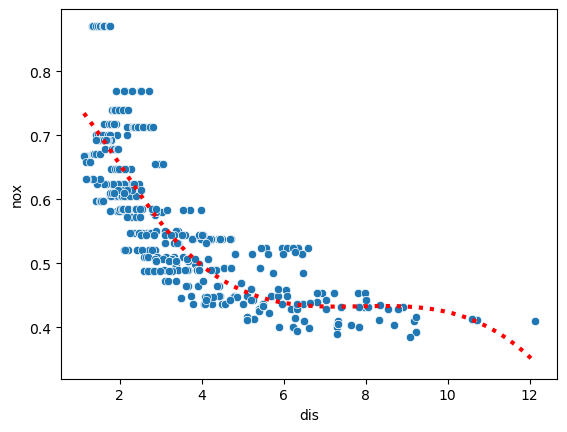

In [122]:
pipe = Pipeline(
    [
        ('spline',SplineTransformer(degree=3,n_knots=3,knots='quantile')),('lr',LinearRegression())
    ]

)
pipe.fit(X,y)
ys = pipe.predict(xs)
plt.plot(xs,ys,'r:',linewidth=3)

sns.scatterplot(data=boston,x='dis',y='nox')
plt.show()

## (e)
```{admonition}
:class: note
Now fit a regression spline for a range of degrees of freedom, and plot the resulting fits and report the resulting RSS. Describe the results obtained.

Degrees of freedom 3 model RSS: 0.1911
Degrees of freedom 4 model RSS: 0.1900
Degrees of freedom 5 model RSS: 0.1818
Degrees of freedom 6 model RSS: 0.1812
Degrees of freedom 7 model RSS: 0.1808
Degrees of freedom 8 model RSS: 0.1795
Degrees of freedom 9 model RSS: 0.1804
Degrees of freedom 10 model RSS: 0.1771
Degrees of freedom 11 model RSS: 0.1776
Degrees of freedom 12 model RSS: 0.1768


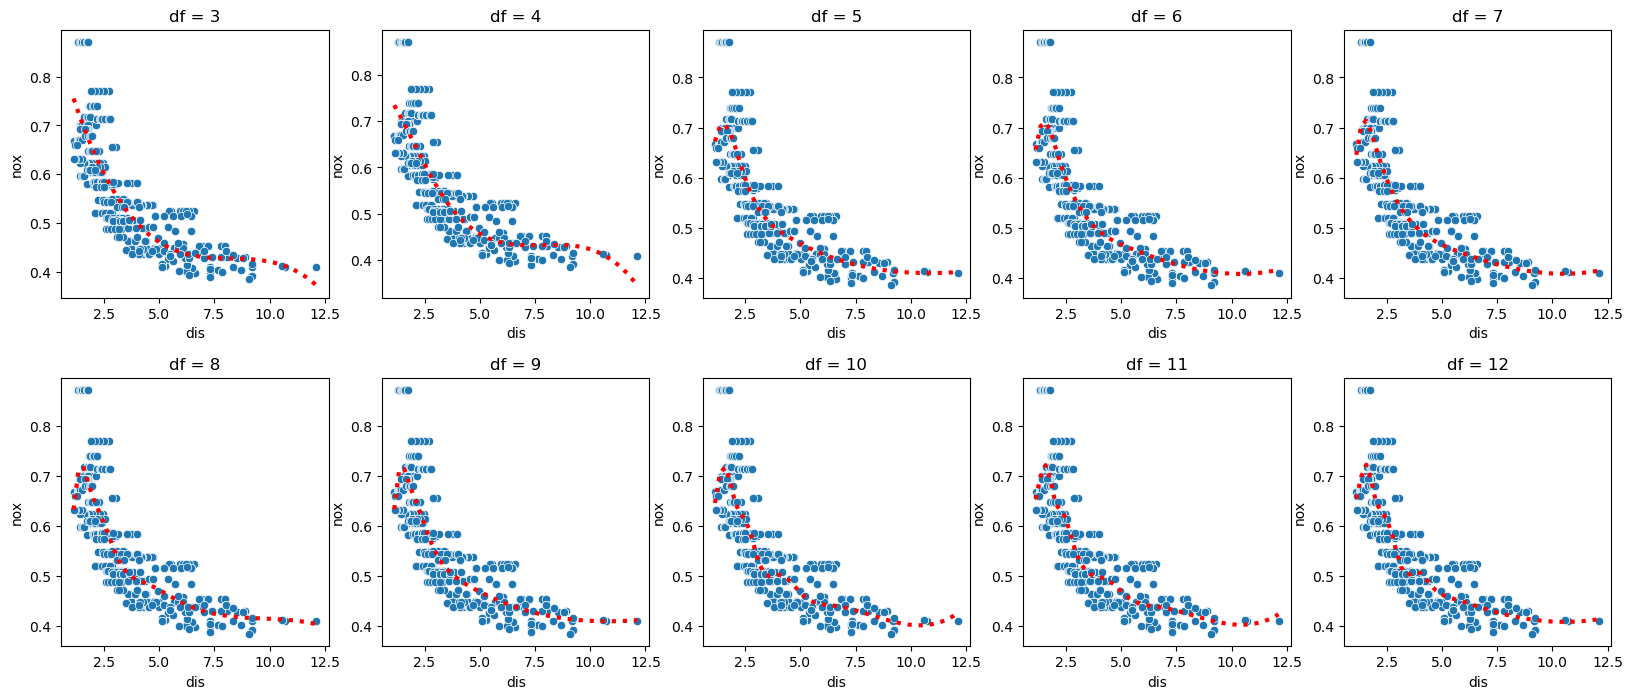

In [123]:
fig,ax = plt.subplots(2,5,figsize=(20,8))
fig.subplots_adjust(hspace=0.3)
ax = ax.flatten()
xs = pd.DataFrame({'dis':np.linspace(X.min().values[0],X.max().values[0])})
rss = np.zeros(10)
for d,axis in enumerate(ax):
    pipe = Pipeline(
        [
            ('spline',SplineTransformer(degree=3,n_knots=d+2,knots='quantile')),('lr',LinearRegression())
        ]
    )
    pipe.fit(X,y) 
    ys = pipe.predict(xs)
    y_pred = pipe.predict(X)
    rss[d] = len(ys)*mean_squared_error(y_pred,y)
    axis.plot(xs,ys,'r:',linewidth=3)
    sns.scatterplot(data=boston,x='dis',y='nox',ax=axis)
    axis.set_title(f'df = {d+3}')
for d,model_rss in enumerate(rss):
    print(f'Degrees of freedom {d+3} model RSS: {model_rss:.4f}')
plt.show()

## (f)
```{admonition}
:class: note
Perform cross-validation or another approach in order to select the best degrees of freedom for a regression spline on this data. Describe your results.

CV average MSE: 0.0037
Degree used: 2
Knots used: 8
Degrees of freedom:10


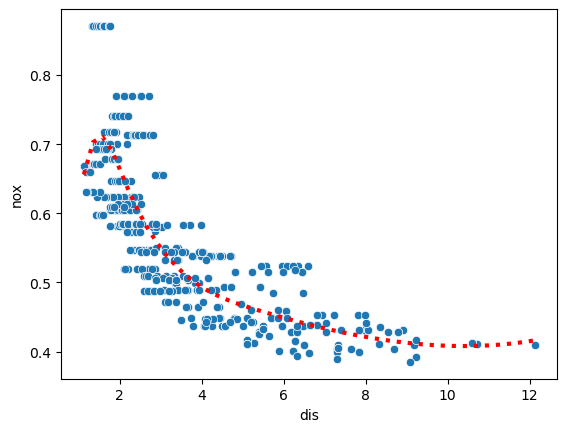

In [127]:
pipe = Pipeline(
    [
        ('spline',SplineTransformer(degree=3,knots='quantile')),('lr',LinearRegression())
    ]

)
inner_cv = KFold(shuffle=True,random_state=1728,n_splits=10)
outer_cv = KFold(shuffle=True,random_state=1729,n_splits=10)
param_grid = {'spline__degree':np.arange(1,6),'spline__n_knots':np.arange(2,20)}

gridsearch = GridSearchCV(pipe,param_grid=param_grid,scoring='neg_mean_squared_error',cv=inner_cv,n_jobs=-1)
cv_mse = -cross_val_score(gridsearch,X,y,cv=outer_cv).mean()

gridsearch.fit(X,y)
best_degree = gridsearch.best_params_['spline__degree']
best_knots = gridsearch.best_params_['spline__n_knots']

print(f'CV average MSE: {cv_mse:.4f}')
print(f'Degree used: {best_degree}')
print(f'Knots used: {best_knots}')
print(f'Degrees of freedom:{best_knots+best_degree}')

pipe.fit(X,y)
ys = pipe.predict(xs)
plt.plot(xs,ys,'r:',linewidth=3)

sns.scatterplot(data=boston,x='dis',y='nox')
plt.show()